# Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

# Load Dataset

In [3]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\creditcard.csv\creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Dataset Overview

In [4]:
print(df.shape)

df.info()

df.describe()

(284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 2

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


# Missing Values

In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

# Duplicate Check

In [6]:
df.duplicated().sum()

np.int64(1081)

In [7]:
df = df.drop_duplicates()

# Class Distribution

In [8]:
print(df["Class"].value_counts())

Class
0    283253
1       473
Name: count, dtype: int64


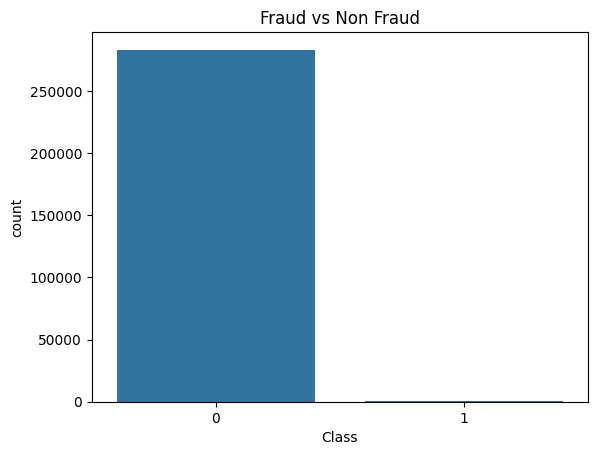

In [9]:
# Visualization:
sns.countplot(x="Class", data=df)

plt.title("Fraud vs Non Fraud")

plt.show()

# Fraud Percentage

In [10]:
fraud_percentage = (
    df["Class"].value_counts(normalize=True)*100
)

print(fraud_percentage)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


# Business Insight:

Dataset is highly imbalanced. Fraud transactions represent only 0.17% of all transactions.

# Amount Distribution

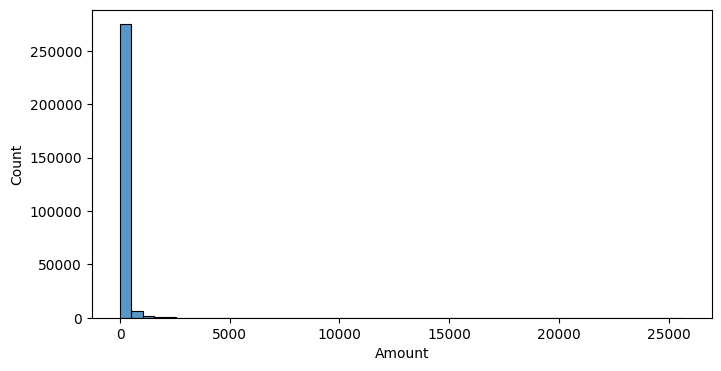

In [11]:
plt.figure(figsize=(8,4))

sns.histplot(
    df["Amount"],
    bins=50
)

plt.show()

# Fraud vs Amount

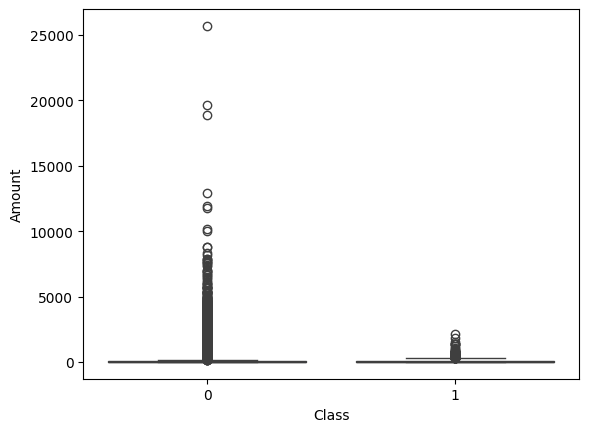

In [12]:
sns.boxplot(
    x="Class",
    y="Amount",
    data=df
)

plt.show()

# Correlation Heatmap

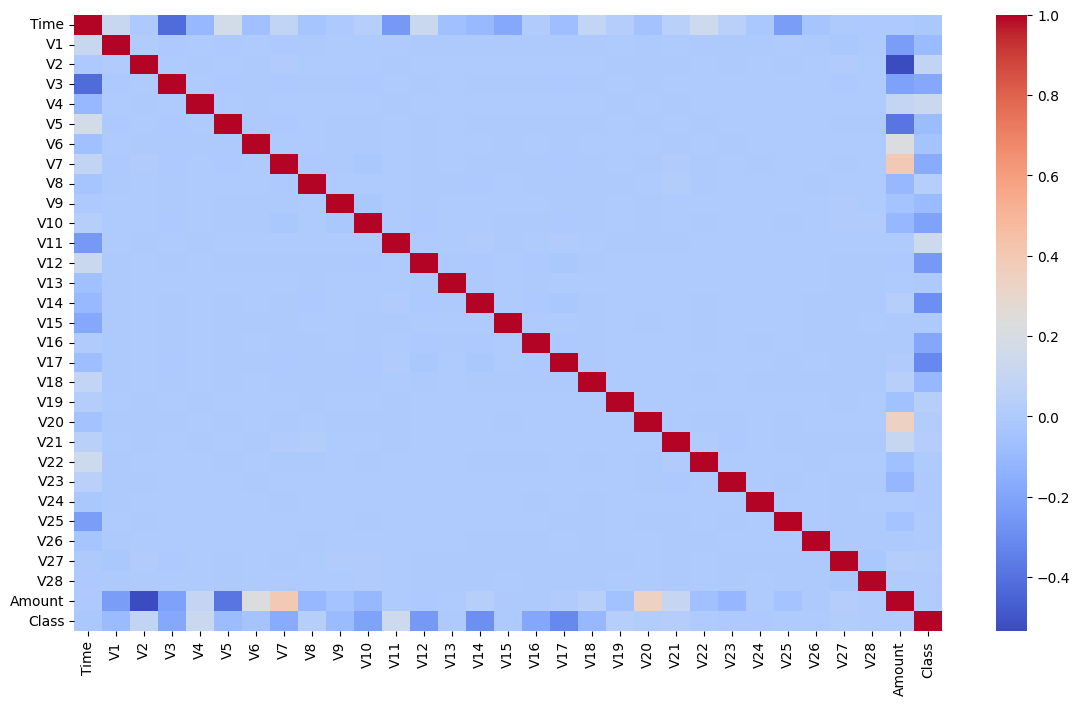

In [13]:
plt.figure(figsize=(14,8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.show()

# Scale Amount

In [14]:
scaler = StandardScaler()

df["Amount"] = scaler.fit_transform(
    df[["Amount"]]
)

# Features & Target

In [15]:
X = df.drop("Class", axis=1)

y = df["Class"]

# Train Test Split

In [16]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check Class Distribution

In [17]:
print("Training Data")

print(y_train.value_counts())

print()

print("Testing Data")

print(y_test.value_counts())

Training Data
Class
0    226602
1       378
Name: count, dtype: int64

Testing Data
Class
0    56651
1       95
Name: count, dtype: int64


# Apply SMOTE

In [18]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Verify SMOTE

In [19]:
print("Before SMOTE")

print(y_train.value_counts())

print()

print("After SMOTE")

print(y_train_smote.value_counts())

Before SMOTE
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE
Class
0    226602
1    226602
Name: count, dtype: int64


# Random Forest Model

In [20]:
from sklearn.ensemble import RandomForestClassifier
print("Training Started...")

rf = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_smote, y_train_smote)

print("Training Completed...")

Training Started...
Training Completed...


# Prediction

In [21]:
pred_rf = rf.predict(X_test)

# Accuracy

In [22]:
from sklearn.metrics import accuracy_score

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred_rf
    )
)

Accuracy: 0.9994537059880872


# Classification Report

In [23]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred_rf
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.89      0.77      0.82        95

    accuracy                           1.00     56746
   macro avg       0.94      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746



# Confusion Matrix

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    pred_rf
)

print(cm)

[[56642     9]
 [   22    73]]


# Confusion Matrix Visualization

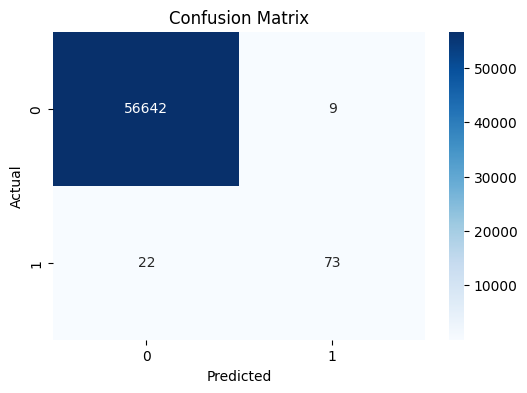

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# Precision, Recall, F1

In [26]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

print(
    "Precision:",
    precision_score(
        y_test,
        pred_rf
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        pred_rf
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        pred_rf
    )
)

Precision: 0.8902439024390244
Recall: 0.7684210526315789
F1 Score: 0.8248587570621468


# ROC-AUC

In [27]:
from sklearn.metrics import roc_auc_score

prob = rf.predict_proba(
    X_test
)[:,1]

print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        prob
    )
)

ROC AUC: 0.9474191471512095


In [28]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(
    X_train_smote,
    y_train_smote
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


# Prediction

In [29]:
pred_xgb = xgb.predict(X_test)

# Accuracy

In [30]:
from sklearn.metrics import accuracy_score

print(
    "XGBoost Accuracy:",
    accuracy_score(
        y_test,
        pred_xgb
    )
)

XGBoost Accuracy: 0.9993479716632009


# Classification Report

In [31]:
print(
    classification_report(
        y_test,
        pred_xgb
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.81      0.80      0.80        95

    accuracy                           1.00     56746
   macro avg       0.90      0.90      0.90     56746
weighted avg       1.00      1.00      1.00     56746



# Precision Recall F1

In [32]:
print(
    "Precision:",
    precision_score(
        y_test,
        pred_xgb
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        pred_xgb
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        pred_xgb
    )
)

Precision: 0.8085106382978723
Recall: 0.8
F1 Score: 0.8042328042328042


# ROC AUC

In [33]:
prob_xgb = xgb.predict_proba(
    X_test
)[:,1]

print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        prob_xgb
    )
)

ROC AUC: 0.9613494071271097


# Final Comparison Table

In [34]:
results = pd.DataFrame({

    "Model":[
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test,pred_rf),
        accuracy_score(y_test,pred_xgb)
    ],

    "Recall":[
        recall_score(y_test,pred_rf),
        recall_score(y_test,pred_xgb)
    ],

    "F1":[
        f1_score(y_test,pred_rf),
        f1_score(y_test,pred_xgb)
    ]

})

print(results)

           Model  Accuracy    Recall        F1
0  Random Forest  0.999454  0.768421  0.824859
1        XGBoost  0.999348  0.800000  0.804233


In [35]:
print("RF ROC AUC:", roc_auc_score(y_test, prob))
print("XGB ROC AUC:", roc_auc_score(y_test, prob_xgb))

RF ROC AUC: 0.9474191471512095
XGB ROC AUC: 0.9613494071271097


# Pickle File Save Karo

In [40]:
import pickle

pickle.dump(
    xgb,
    open("fraud_model.pkl", "wb")
)

print("Model Saved Successfully")

Model Saved Successfully


# Feature List Save Karo

In [37]:
print(X.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


# Feature Importance

In [38]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": xgb.feature_importances_

})

importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
14,V14,0.673521
12,V12,0.043636
4,V4,0.042533
17,V17,0.032365
8,V8,0.015228
3,V3,0.013934
11,V11,0.013025
1,V1,0.012777
10,V10,0.012363
9,V9,0.011510


<Axes: xlabel='Importance', ylabel='Feature'>

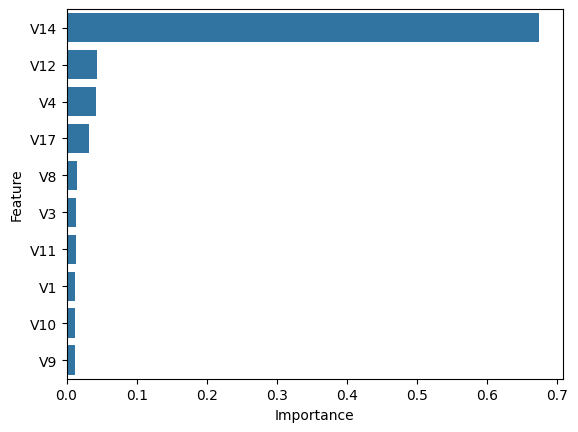

In [39]:
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.sort_values(
        by="Importance",
        ascending=False
    ).head(10)
)